# Task 5 — PI Hyperconnected Network: Full Evaluation
**Subtasks covered:** 5.1 Network design · 5.2 Container/p-pack · 5.3 Transport time (MC) · 5.4 Joint shipment · 5.5 Demand uplift · 5.6 Autonomy · 5.9 Cost+Carbon · 5.10 DC sizing · 5.11 Transload · 5.12 Profitability

In [1]:
import sys
from pathlib import Path

CWD = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in [CWD, CWD.parent, CWD.parent.parent]
        if (candidate / 'Task5' / 'src' / 'pipeline.py').exists()
    ),
    CWD,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', '{:.3f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FIGSIZE = (14, 5)
OUTPUT_DIR = REPO_ROOT / 'Task5' / 'output'
DATA_DIR   = REPO_ROOT / 'Task5' / 'data'
print('Repo root:', REPO_ROOT)


Repo root: /home/hty/Documents/Working Projects/ISYE6339_Case1


## Run full pipeline (2027–2034)

In [ ]:
from Task5.src.pipeline import run_pipeline, print_kpi_summary

results = run_pipeline(force_rebuild=True, verbose=True, n_sim=1000)
print()
print_kpi_summary(results)

print("""
Output files written to Task5/output/
======================================
[5.1]  network_kpis_by_year.csv            — PI network KPIs per year
[5.1]  network_roadmap_{year}.csv          — per-year active node roster
[5.1]  activation_decisions_log.csv        — newly activated nodes per year
[5.2]  subtask_5_2_container_space.csv     — pallet/TEU/p-pack savings per year
[5.3]  subtask_5_3_otd_attainment_by_bracket.csv — route-based PI OTD attainment by pop bracket
[5.3]  otd_simulation_{year}.csv           — route-based OTD sim rows per year
[5.4]  subtask_5_4_joint_shipment_trace.csv — illustrative multi-leg trace
[5.5]  subtask_5_5_pi_demand_summary.csv   — PI realized demand summary per year
[5.6]  subtask_5_6_autonomy.csv            — relay readiness & dual-role hub % per year
[5.9]  subtask_5_9_cost_carbon_summary.csv — PI transport cost, truckloads, and CO2 per year
[5.9]  lane_cost_carbon_{year}.csv         — routed lane cost & CO2 detail per year
[5.10] subtask_5_10_dc_demand_intervals.csv — simulator-backed annual demand intervals per DC
[5.10] dc_capacity_{year}.csv              — DC sizing & cyber-week stress per year
[5.11] subtask_5_11_transload.csv          — transload handling cost per year
[5.12] subtask_5_12_profitability.csv      — PI P&L summary per year
[5.12] profitability_by_year.csv           — same (legacy name)
""")


---
## Task 5.1 — Network Topology KPIs

In [3]:
kpi_df = pd.read_csv(OUTPUT_DIR / 'network_kpis_by_year.csv')
display(kpi_df[[
    'year','n_dc','n_peri_urban_hub','n_border_relay_hub',
    'n_lanes_total','coverage_pct','relay_readiness_pct',
    'dc_dc_connectivity_pct','mean_detour','max_detour',
]].set_index('year'))

,n_dc,n_peri_urban_hub,n_border_relay_hub,n_lanes_total,coverage_pct,relay_readiness_pct,dc_dc_connectivity_pct,mean_detour,max_detour
year,,,,,,,,,
2027,1,71,0,2644,100.000,98.110,100.000,1.200,1.203
2028,2,111,3,3225,99.100,97.400,100.000,1.200,1.203
2029,3,232,8,5175,96.980,96.230,100.000,1.200,1.217
2030,4,269,12,5815,97.400,95.460,100.000,1.200,1.217
2031,4,269,12,5815,97.400,95.460,100.000,1.200,1.217
2032,4,269,12,5815,97.400,95.460,100.000,1.200,1.217
2033,4,269,12,5815,97.400,95.460,100.000,1.200,1.217
2034,4,269,12,5815,97.400,95.460,100.000,1.200,1.217


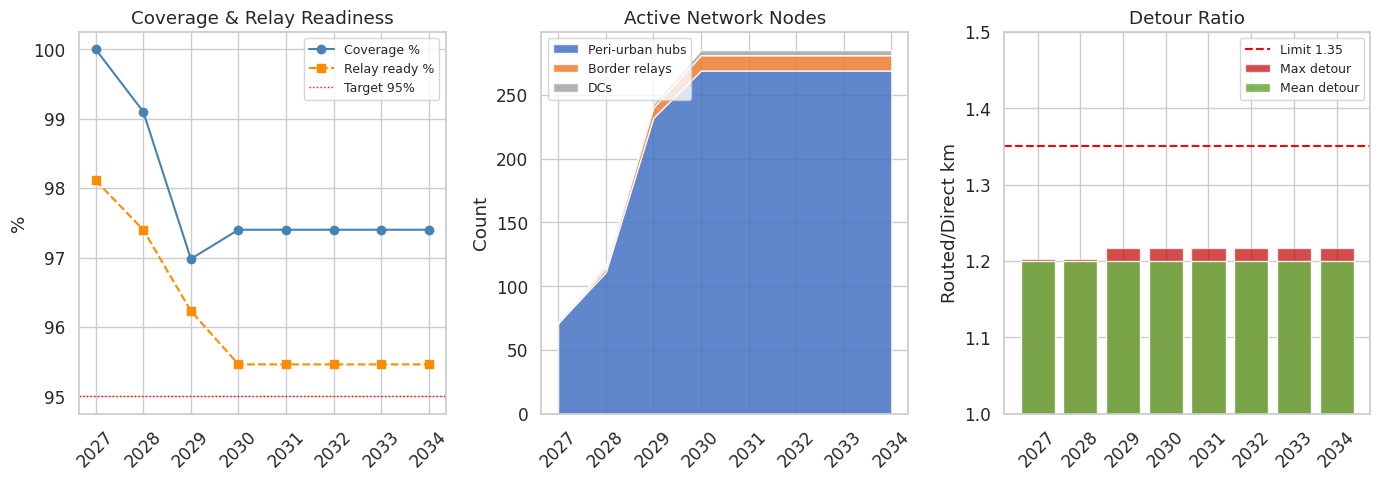

In [4]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)
years = kpi_df['year']

# Panel 1: Coverage + relay readiness
ax = axes[0]
ax.plot(years, kpi_df['coverage_pct'], 'o-', label='Coverage %', color='steelblue')
ax.plot(years, kpi_df['relay_readiness_pct'], 's--', label='Relay ready %', color='darkorange')
ax.axhline(95, color='red', linestyle=':', lw=1, label='Target 95%')
ax.set_title('Coverage & Relay Readiness'); ax.set_ylabel('%'); ax.legend(fontsize=9)
ax.set_xticks(years); ax.tick_params(axis='x', rotation=45)

# Panel 2: Node counts by type
ax = axes[1]
ax.stackplot(years,
    kpi_df.get('n_peri_urban_hub', 0),
    kpi_df.get('n_border_relay_hub', 0),
    kpi_df.get('n_dc', 0),
    labels=['Peri-urban hubs','Border relays','DCs'],
    colors=['#4472C4','#ED7D31','#A5A5A5'], alpha=0.85
)
ax.set_title('Active Network Nodes'); ax.set_ylabel('Count'); ax.legend(loc='upper left', fontsize=9)
ax.set_xticks(years); ax.tick_params(axis='x', rotation=45)

# Panel 3: Detour ratio
ax = axes[2]
ax.bar(years, kpi_df['max_detour'], color='#C00000', alpha=0.7, label='Max detour')
ax.bar(years, kpi_df['mean_detour'], color='#70AD47', alpha=0.9, label='Mean detour')
ax.axhline(1.35, color='red', linestyle='--', lw=1.5, label='Limit 1.35')
ax.set_title('Detour Ratio'); ax.set_ylabel('Routed/Direct km'); ax.legend(fontsize=9)
ax.set_xticks(years); ax.set_ylim(1.0, 1.5); ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5_1_topology_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

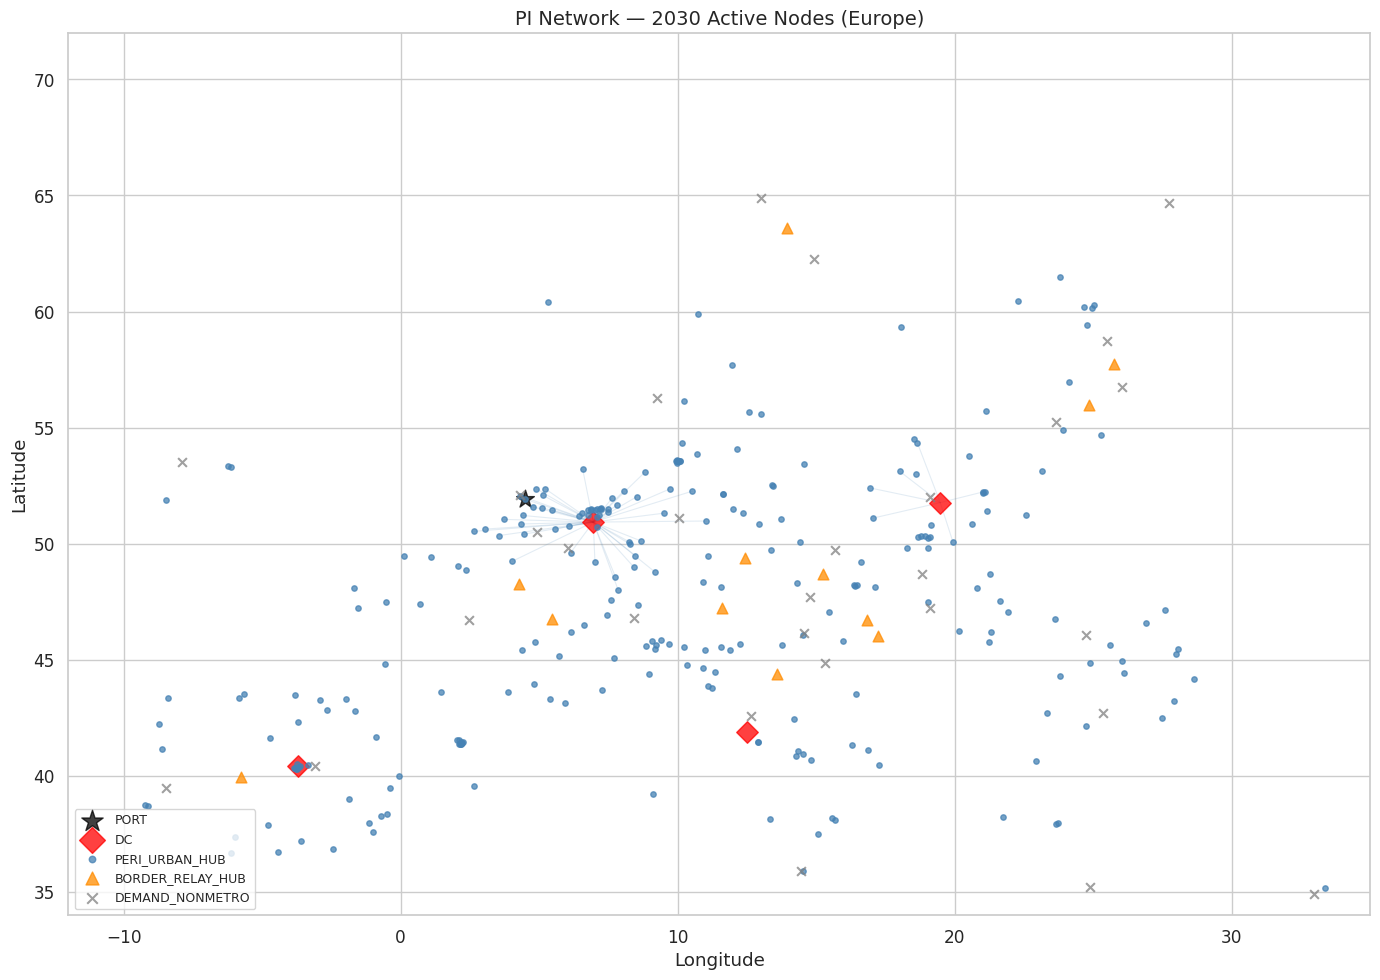

In [5]:
# Network scatter map — 2030 (full network)
res_2030 = next(r for r in results if r['year'] == 2030)
nodes_2030 = res_2030['active_nodes']

type_style = {
    'PORT':             ('*', 180, 'black'),
    'DC':               ('D', 120, 'red'),
    'PERI_URBAN_HUB':   ('o', 15,  'steelblue'),
    'BORDER_RELAY_HUB': ('^', 60,  'darkorange'),
    'DEMAND_NONMETRO':  ('x', 40,  'grey'),
}

fig, ax = plt.subplots(figsize=(14, 10))
for ntype, (marker, size, color) in type_style.items():
    sub = nodes_2030[nodes_2030['node_type'] == ntype]
    if sub.empty:
        continue
    ax.scatter(sub['lng'], sub['lat'], marker=marker, s=size,
               color=color, label=ntype, alpha=0.75, zorder=3)

# Draw DC→hub direct lanes (sample)
lanes_2030 = res_2030['lanes']
direct = lanes_2030[lanes_2030['lane_type'] == 'DC_HUB_DIRECT'].head(60)
node_loc = nodes_2030.set_index('node_id')[['lat','lng']]
for _, row in direct.iterrows():
    try:
        o = node_loc.loc[row['origin_id']]; d = node_loc.loc[row['dest_id']]
        ax.plot([o['lng'], d['lng']], [o['lat'], d['lat']],
                color='steelblue', alpha=0.15, lw=0.8)
    except KeyError:
        pass

ax.set_title('PI Network — 2030 Active Nodes (Europe)', fontsize=14)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=9, markerscale=1.2)
ax.set_xlim(-12, 35); ax.set_ylim(34, 72)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5_1_network_map_2030.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 5.2 — Container / p-pack Space Requirements

In [ ]:
container_rows = [r['container_analysis'] for r in results]
cont_df = pd.DataFrame(container_rows)
cont_df.insert(0, 'year', [r['year'] for r in results])

cont_view = cont_df[
    ['year', 'annual_units', 'pallets_pi', 'teus_pi',
     'pallet_saving_pct', 'teu_saving_pct',
     'pack_cost_saving_eur', 'container_saving_eur']
].rename(columns={
    'pallets_pi': 'pi_pallets',
    'teus_pi': 'pi_teus',
})

display(cont_view.set_index('year'))


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)
years_arr = cont_df['year'].values

# Panel 1: PI pallet requirement
ax = axes[0]
ax.bar(years_arr, cont_df['pallets_pi'], color='#70AD47', alpha=0.85)
ax.set_title('Annual PI Pallet Requirement')
ax.set_ylabel('Pallets')
ax.tick_params(axis='x', rotation=45)

# Panel 2: PI TEU requirement
ax = axes[1]
ax.bar(years_arr, cont_df['teus_pi'], color='#4472C4', alpha=0.85)
ax.set_title('Annual PI Container (TEU) Requirement')
ax.set_ylabel('TEUs')
ax.tick_params(axis='x', rotation=45)

# Panel 3: PI-enabled savings
ax = axes[2]
ax.bar(years_arr, cont_df['pack_cost_saving_eur'] / 1e6, label='Pack cost saving', color='steelblue', alpha=0.85)
ax.bar(
    years_arr,
    cont_df['container_saving_eur'] / 1e6,
    bottom=cont_df['pack_cost_saving_eur'] / 1e6,
    label='Container saving',
    color='darkorange',
    alpha=0.85,
)
ax.set_title('Annual PI Cost Savings (€M)')
ax.set_ylabel('€ Millions')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5_2_container_savings.png', dpi=150, bbox_inches='tight')
plt.show()

# PI p-pack footprint illustration
from Task5.src.config import BOT_NONPI_VOL_CM3, BOT_PI_PACK_VOL_CM3

pi_litres = BOT_PI_PACK_VOL_CM3 / 1000
reduction_pct = (1 - BOT_PI_PACK_VOL_CM3 / BOT_NONPI_VOL_CM3) * 100

fig2, ax2 = plt.subplots(figsize=(5, 4))
ax2.bar(['PI p-pack'], [pi_litres], color='#70AD47', width=0.5)
ax2.set_ylabel('Volume per unit (litres)')
ax2.set_title(f'PI p-pack volume ({reduction_pct:.0f}% below baseline box)')
ax2.text(0, pi_litres + 2, f'{pi_litres:.0f} L', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5_2_ppack_volume.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Task 5.3 — Transport Time Reduction (Monte Carlo Simulation)

In [ ]:
# Load route-based OTD simulation for 2030
res_2030 = next((r for r in results if r['year'] == 2030), None)
if res_2030 is None or res_2030['otd_sim_df'].empty:
    print('No OTD simulation data for 2030 — check route-backed OTD outputs')
else:
    cols = ['pop_bracket', 'n_hubs', 'pi_promise_hr', 'mean_attainment', 'mean_p50_elapsed']
    display(res_2030['otd_by_bracket'][cols])


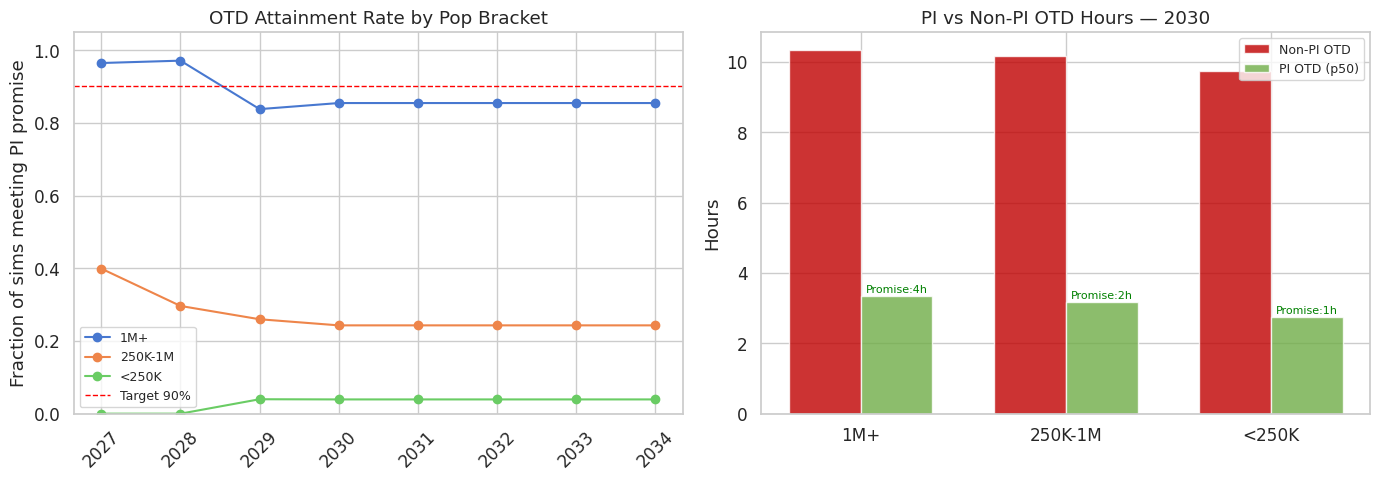

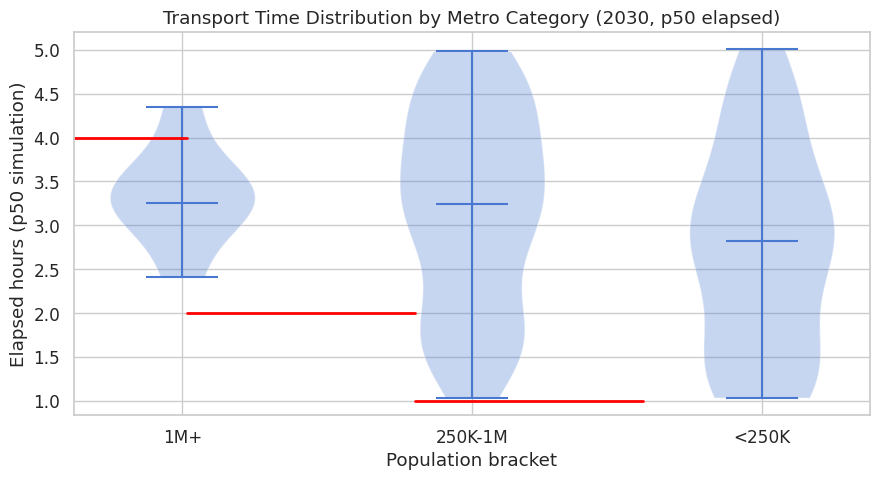

In [9]:
# OTD attainment by pop_bracket + PI route performance trend
attn_rows = []
for res in results:
    if not res['otd_by_bracket'].empty:
        sub = res['otd_by_bracket'].copy()
        sub['year'] = res['year']
        attn_rows.append(sub)

if attn_rows:
    attn_all = pd.concat(attn_rows, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

    # Panel 1: Attainment over years by bracket
    ax = axes[0]
    for bracket, grp in attn_all.groupby('pop_bracket'):
        ax.plot(grp['year'], grp['mean_attainment'], 'o-', label=bracket)
    ax.axhline(0.9, linestyle='--', color='red', lw=1, label='Target 90%')
    ax.set_title('PI OTD Attainment by Population Bracket')
    ax.set_ylabel('Fraction of sims meeting promise')
    ax.set_xticks(attn_all['year'].unique())
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

    # Panel 2: 2030 PI median elapsed vs promise
    ax = axes[1]
    br_2030 = attn_all[attn_all['year'] == 2030].reset_index(drop=True)
    if not br_2030.empty:
        x_pos = np.arange(len(br_2030))
        ax.bar(x_pos, br_2030['mean_p50_elapsed'], color='#70AD47', alpha=0.85, label='PI route OTD (p50)')
        ax.scatter(x_pos, br_2030['pi_promise_hr'], color='red', marker='D', s=55, label='Promise')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(br_2030['pop_bracket'], rotation=0)
        ax.set_title('PI Median OTD vs Promise — 2030')
        ax.set_ylabel('Hours')
        ax.legend(fontsize=9)
        for i, row in enumerate(br_2030.itertuples()):
            ax.text(i, row.mean_p50_elapsed + 0.1, f'{row.mean_attainment:.0%}', ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_5_3_otd_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Violin plot of route-based elapsed distributions for 2030
    otd_2030 = next((r['otd_sim_df'] for r in results if r['year'] == 2030), pd.DataFrame())
    if not otd_2030.empty:
        fig3, ax3 = plt.subplots(figsize=(9, 5))
        data_by_bracket = [
            otd_2030[otd_2030['pop_bracket'] == b]['p50_elapsed_hr'].values
            for b in ['1M+', '250K-1M', '<250K']
            if b in otd_2030['pop_bracket'].values
        ]
        labels = [b for b in ['1M+', '250K-1M', '<250K'] if b in otd_2030['pop_bracket'].values]
        if data_by_bracket:
            ax3.violinplot(data_by_bracket, showmedians=True)
            ax3.set_xticks(range(1, len(labels) + 1))
            ax3.set_xticklabels(labels)
            for i, (lbl, promise) in enumerate(zip(['1M+', '250K-1M', '<250K'], [4, 2, 1]), 1):
                if lbl in labels:
                    ax3.axhline(
                        promise,
                        xmin=(i - 1.5) / (len(labels) + 0.5),
                        xmax=(i - 0.5) / (len(labels) + 0.5),
                        color='red',
                        lw=2,
                        label=f'Promise {promise}h' if i == 1 else None,
                    )
            ax3.set_title('PI Route Elapsed Distribution by Metro Category (2030)')
            ax3.set_ylabel('Elapsed hours (p50 simulation)')
            ax3.set_xlabel('Population bracket')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'fig_5_3_otd_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('No OTD bracket data available')


---
## Task 5.4 — Joint Shipment Illustrative Trace

Shipment: PORT_NL_rotterdam → METRO_BE_brussels


,step,from_id,to_id,lane_type,drive_hr,dwell_hr,cumulative_elapsed_hr,truck_class,road_km,co2_kg
0,1,PORT_NL_rotterdam,CAND_DE_koeln,PORT_DC,2.443,1.000,3.443,L,244.300,151.450
1,2,CAND_DE_koeln,METRO_BE_brussels,DC_HUB_DIRECT,2.192,1.000,6.635,M,219.200,89.880


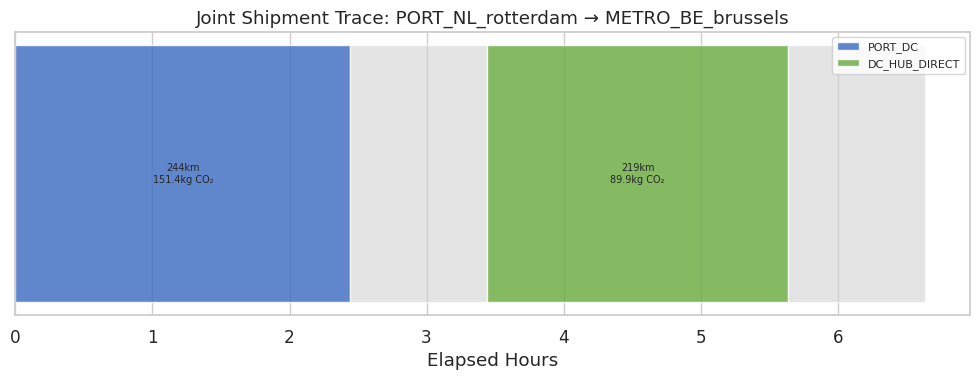

In [10]:
jst = results[0]['joint_shipment_trace']
if jst:
    jst_df = pd.DataFrame(jst)
    print(f"Shipment: {jst_df.iloc[0]['from_id']} → {jst_df.iloc[-1]['to_id']}")
    display(jst_df)

    # Gantt-style elapsed time chart
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = {'PORT_DC': '#4472C4', 'DC_HUB_DIRECT': '#70AD47', 'DC_HUB_VIA_RELAY': '#ED7D31',
              'RELAY_HUB': '#FFC000', 'HUB_CORRIDOR': '#A5A5A5', 'DC_DC': '#C00000'}
    prev = 0
    for i, row in jst_df.iterrows():
        color = colors.get(row['lane_type'], 'lightblue')
        ax.barh(0, row['drive_hr'], left=prev, height=0.4, color=color, alpha=0.85,
                label=row['lane_type'] if i == 0 or row['lane_type'] != jst_df.iloc[i-1]['lane_type'] else '')
        ax.barh(0, row['dwell_hr'], left=prev + row['drive_hr'], height=0.4,
                color='lightgrey', alpha=0.6)
        ax.text(prev + row['drive_hr']/2, 0,
                f"{row['road_km']:.0f}km\n{row['co2_kg']:.1f}kg CO₂",
                ha='center', va='center', fontsize=7)
        prev = row['cumulative_elapsed_hr']

    ax.set_xlabel('Elapsed Hours'); ax.set_yticks([])
    ax.set_title(f"Joint Shipment Trace: {jst_df.iloc[0]['from_id']} → {jst_df.iloc[-1]['to_id']}")
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_5_4_joint_shipment.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No joint shipment trace available')

---
## Task 5.5 — OTD + Reachable Demand Uplift

In [ ]:
pi_summary_rows = [r['pi_demand'].get('uplift_summary', {}) for r in results if r['pi_demand']]
pi_summary_df = pd.DataFrame(pi_summary_rows)
if not pi_summary_df.empty:
    display(pi_summary_df[['year', 'pi_realized_total', 'demand_uplift_pct', 'revenue_uplift_eur']].set_index('year'))

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

    ax = axes[0]
    ax.plot(pi_summary_df['year'], pi_summary_df['pi_realized_total'], 'o-', color='#70AD47', label='PI realized units')
    ax.set_title('PI Realized Demand')
    ax.set_ylabel('Units/year')
    ax.legend(fontsize=9)
    ax.set_xticks(pi_summary_df['year'])
    ax.tick_params(axis='x', rotation=45)

    ax = axes[1]
    ax.bar(pi_summary_df['year'], pi_summary_df['revenue_uplift_eur'] / 1e6, color='steelblue', alpha=0.85, label='Revenue uplift')
    ax2_ = ax.twinx()
    ax2_.plot(pi_summary_df['year'], pi_summary_df['demand_uplift_pct'], 'o--', color='darkorange', label='Demand uplift %')
    ax.set_title('PI Demand Impact vs Baseline')
    ax.set_ylabel('Revenue uplift (€M)', color='steelblue')
    ax2_.set_ylabel('Demand uplift %', color='darkorange')
    ax.set_xticks(pi_summary_df['year'])
    ax.tick_params(axis='x', rotation=45)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2_.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper left')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_5_5_demand_uplift.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Task 5.6 — Autonomy & Relay Readiness

,relay_readiness_pct,dc_dc_relay_required_pct,dual_role_hubs,dual_role_pct
year,,,,
2027,98.110,0.000,0,0.000
2028,97.400,0.000,8,7.210
2029,96.230,66.670,75,32.330
2030,95.460,83.330,93,34.570
2031,95.460,83.330,93,34.570
2032,95.460,83.330,93,34.570
2033,95.460,83.330,93,34.570
2034,95.460,83.330,93,34.570


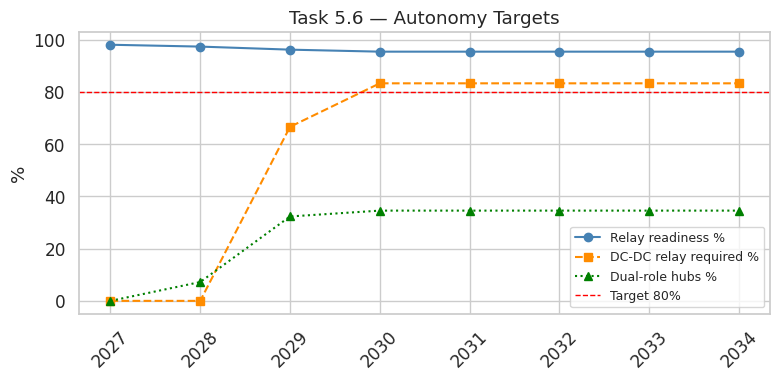

In [12]:
aut_rows = [r['autonomy'] for r in results]
aut_df = pd.DataFrame(aut_rows)
display(aut_df.set_index('year')[['relay_readiness_pct','dc_dc_relay_required_pct','dual_role_hubs','dual_role_pct']])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(aut_df['year'], aut_df['relay_readiness_pct'],      'o-', label='Relay readiness %', color='steelblue')
ax.plot(aut_df['year'], aut_df['dc_dc_relay_required_pct'], 's--', label='DC-DC relay required %', color='darkorange')
ax.plot(aut_df['year'], aut_df['dual_role_pct'],            '^:', label='Dual-role hubs %', color='green')
ax.axhline(80, linestyle='--', color='red', lw=1, label='Target 80%')
ax.set_title('Task 5.6 — Autonomy Targets'); ax.set_ylabel('%'); ax.legend(fontsize=9)
ax.set_xticks(aut_df['year']); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5_6_autonomy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 5.9 — Shipment / Truck / Distance / Cost / Carbon

In [13]:
# Load 2030 lane cost details
lc_file = OUTPUT_DIR / 'lane_cost_carbon_2030.csv'
if lc_file.exists():
    lc_2030 = pd.read_csv(lc_file)
    print(f"Lane cost 2030: {len(lc_2030)} lanes")
    summary_2030 = lc_2030.groupby('lane_type')[['annual_flow', 'truckloads', 'transport_cost_eur', 'co2_kg', 'road_km']].sum().round(0)
    display(summary_2030)


Lane cost 2030: 5815 lanes


,transport_cost_eur,co2_kg,road_km
lane_type,,,
DC_DC,1963665.000,1058672.000,19561.000
DC_HUB_DIRECT,1610977.000,880668.000,21763.000
DC_HUB_VIA_RELAY,17819558.000,9607066.000,166615.000
DC_RELAY,2056417.000,1108677.000,19311.000
HUB_CORRIDOR,0.000,0.000,1129877.000
PORT_DC,0.000,0.000,4711.000
RELAY_HUB,0.000,0.000,38346.000


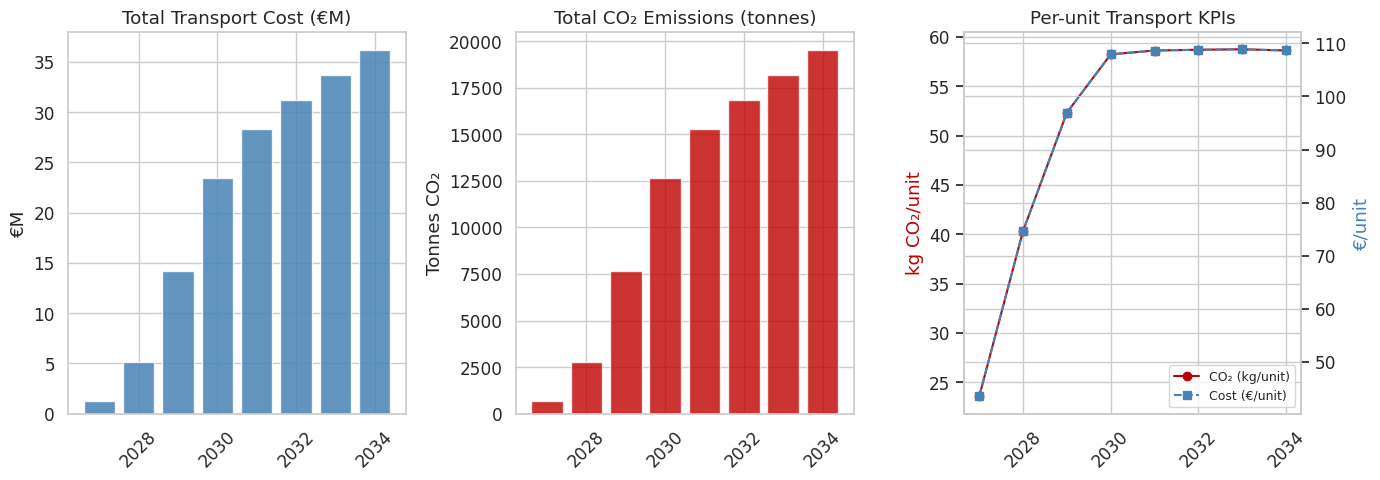

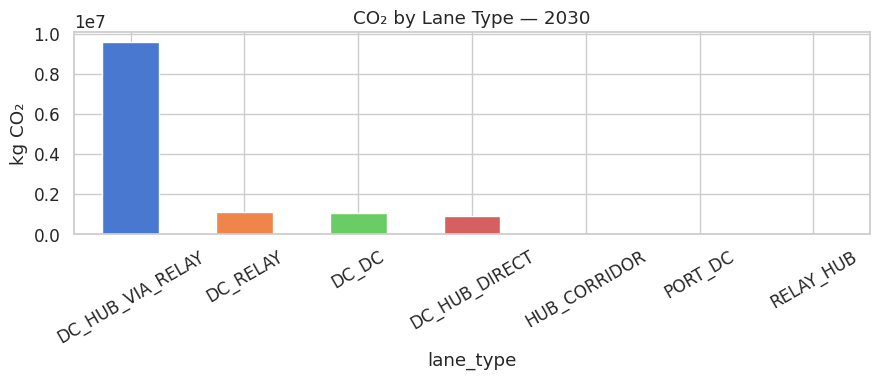

In [14]:
# Aggregate PI cost + carbon by year
cost_rows = []
for res in results:
    lc = res['lane_cost_df']
    if not lc.empty:
        cost_rows.append({
            'year': res['year'],
            'total_transport_eur': lc['transport_cost_eur'].sum(),
            'total_co2_kg': lc['co2_kg'].sum(),
            'total_flow': lc['annual_flow'].sum(),
            'total_truckloads': lc['truckloads'].sum() if 'truckloads' in lc.columns else np.nan,
        })

cost_df = pd.DataFrame(cost_rows)
if not cost_df.empty:
    cost_df['co2_per_unit'] = cost_df['total_co2_kg'] / cost_df['total_flow'].clip(lower=1)
    cost_df['cost_per_unit'] = cost_df['total_transport_eur'] / cost_df['total_flow'].clip(lower=1)
    display(cost_df.set_index('year')[['total_transport_eur', 'total_truckloads', 'total_co2_kg', 'cost_per_unit', 'co2_per_unit']])

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    ax = axes[0]
    ax.bar(cost_df['year'], cost_df['total_transport_eur'] / 1e6, color='steelblue', alpha=0.85)
    ax.set_title('Total Transport Cost (€M)')
    ax.set_ylabel('€M')
    ax.tick_params(axis='x', rotation=45)

    ax = axes[1]
    ax.bar(cost_df['year'], cost_df['total_truckloads'], color='darkorange', alpha=0.85)
    ax.set_title('Total Truckloads')
    ax.set_ylabel('Truckloads')
    ax.tick_params(axis='x', rotation=45)

    ax = axes[2]
    ax.bar(cost_df['year'], cost_df['total_co2_kg'] / 1e3, color='#C00000', alpha=0.8)
    ax.set_title('Total CO2 Emissions (tonnes)')
    ax.set_ylabel('Tonnes CO2')
    ax.tick_params(axis='x', rotation=45)

    ax = axes[3]
    ax.plot(cost_df['year'], cost_df['co2_per_unit'], 'o-', color='#C00000', label='CO2 (kg/unit)')
    ax2_ = ax.twinx()
    ax2_.plot(cost_df['year'], cost_df['cost_per_unit'], 's--', color='steelblue', label='Cost (€/unit)')
    ax.set_title('Per-unit Transport KPIs')
    ax.set_ylabel('kg CO2/unit', color='#C00000')
    ax2_.set_ylabel('€/unit', color='steelblue')
    ax.tick_params(axis='x', rotation=45)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2_.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_5_9_cost_carbon.png', dpi=150, bbox_inches='tight')
    plt.show()

    if lc_file.exists():
        co2_by_type = lc_2030.groupby('lane_type')['co2_kg'].sum().sort_values(ascending=False)
        fig2, ax_co2 = plt.subplots(figsize=(9, 4))
        co2_by_type.plot(kind='bar', ax=ax_co2, color=sns.color_palette('muted', len(co2_by_type)))
        ax_co2.set_title('CO2 by Lane Type — 2030')
        ax_co2.set_ylabel('kg CO2')
        ax_co2.tick_params(axis='x', rotation=30)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'fig_5_9_carbon_by_lane.png', dpi=150, bbox_inches='tight')
        plt.show()


---
## Task 5.10 — DC Capacity Sizing (Simulation-backed)

In [15]:
# Compile DC capacity across years
dc_cap_rows = []
for res in results:
    if not res['dc_capacity'].empty:
        dc_sub = res['dc_capacity'].copy(); dc_sub['year'] = res['year']
        dc_cap_rows.append(dc_sub)

if dc_cap_rows:
    dc_cap_all = pd.concat(dc_cap_rows, ignore_index=True)
    display(dc_cap_all[['year','dc_id','annual_units','p95_peak_daily_units',
                          'throughput_cap_pallets','storage_positions','dc_total_cost_eur']].set_index(['year','dc_id']))

annual_units  p95_peak_daily_units  throughput_cap_pallets  storage_positions  dc_total_cost_eur
year dc_id                                                                                                           
2027 CAND_DE_koeln      28430.000              1060.000                     354                182         756802.000
2028 CAND_DE_koeln      50689.000              1889.000                     630                325         879599.000
     CAND_PL_lodz       18215.000               672.000                     226                117         700480.000
2029 CAND_DE_koeln      95595.000              3563.000                    1188                612        1127193.000
     CAND_ES_madrid     16083.000               593.000                     198                103         688649.000
     CAND_PL_lodz       34578.000              1295.000                     432                222         790821.000
2030 CAND_DE_koeln     102862.000              3834.000                    1278                658        1167203.000
     CAND_ES_madrid     27375.000              1010.000                     338                175         750883.000
     CAND_IT_rome       33942.000              1272.000                     424                217         787209.000
     CAND_PL_lodz       53180.000              1982.000                     662                340         893257.000
2031 CAND_DE_koeln     116363.000              4337.000                    1446                744        1241616.000
     CAND_ES_madrid     33531.000              1237.000                     414                215         784885.000
     CAND_IT_rome       44814.000              1679.000                     560                287         847233.000
     CAND_PL_lodz       66054.000              2462.000                     822                423         964323.000
2032 CAND_DE_koeln     126112.000              4701.000                    1568                807        1295468.000
     CAND_ES_madrid     36653.000              1352.000                     452                235         802081.000
     CAND_IT_rome       50223.000              1882.000                     628                322         877119.000
     CAND_PL_lodz       74062.000              2761.000                     922                474        1008463.000
2033 CAND_DE_koeln     135887.000              5065.000                    1690                869        1349324.000
     CAND_ES_madrid     39793.000              1468.000                     490                255         819367.000
     CAND_IT_rome       54452.000              2040.000                     680                349         900421.000
     CAND_PL_lodz       79890.000              2978.000                     994                511        1040565.000
2034 CAND_DE_koeln     145689.000              5430.000                    1812                932        1403416.000
     CAND_ES_madrid     42949.000              1585.000                     530                275         836769.000
     CAND_IT_rome       58680.000              2198.000                     734                376         923770.000
     CAND_PL_lodz       85680.000              3194.000                    1066                548        1072490.000

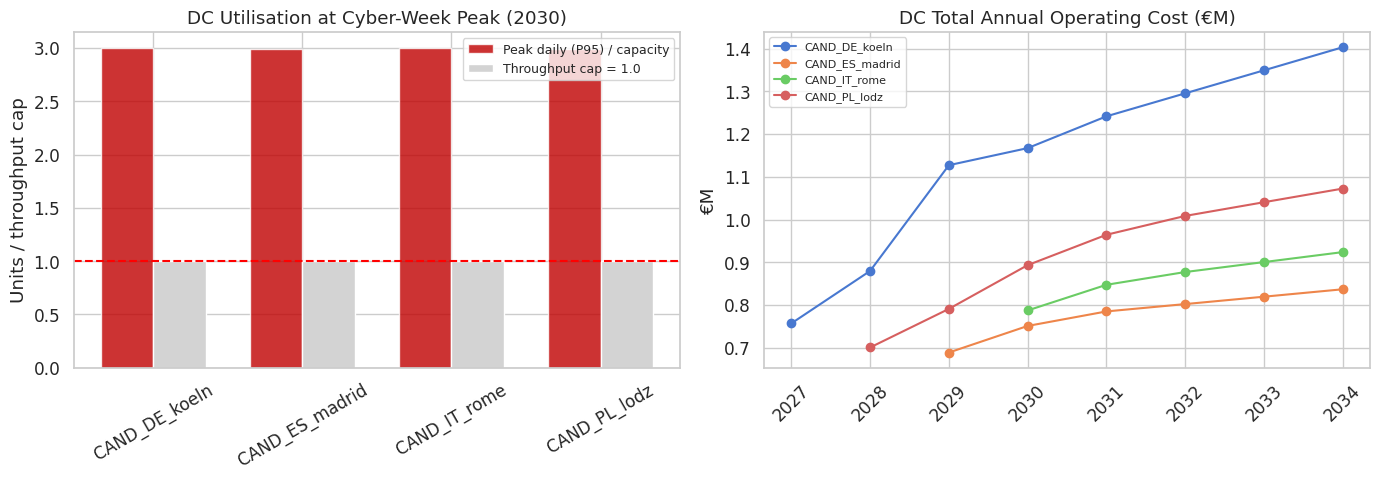

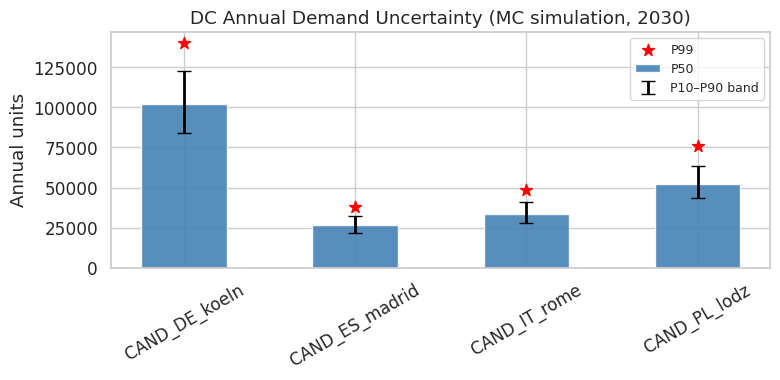

In [16]:
if dc_cap_rows:
    from Task5.src.config import UNITS_PER_PALLET_PI

    # Cyber week stress by DC and year
    cw_rows = []
    for res in results:
        if not res['cyber_stress'].empty:
            cw = res['cyber_stress'].copy()
            cw['year'] = res['year']
            cw_rows.append(cw)
    if cw_rows:
        cw_all = pd.concat(cw_rows, ignore_index=True)

        fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

        # Panel 1: Throughput capacity vs peak daily demand per DC (2030)
        dc_2030 = dc_cap_all[dc_cap_all['year'] == 2030].reset_index(drop=True)
        if not dc_2030.empty:
            ax = axes[0]
            x = np.arange(len(dc_2030))
            w = 0.35
            peak_pallets = dc_2030['p95_peak_daily_units'] / UNITS_PER_PALLET_PI
            ax.bar(x - w / 2, peak_pallets, w, label='Peak daily pallets (P95)', color='#C00000', alpha=0.8)
            ax.bar(x + w / 2, dc_2030['throughput_cap_pallets'], w, label='Throughput capacity', color='lightgrey')
            ax.set_xticks(x)
            ax.set_xticklabels(dc_2030['dc_id'], rotation=30)
            ax.set_title('DC Peak Throughput vs Capacity (2030)')
            ax.set_ylabel('Pallets/day')
            ax.legend(fontsize=9)

        # Panel 2: DC total cost over time
        ax = axes[1]
        for dc_id, grp in dc_cap_all.groupby('dc_id'):
            ax.plot(grp['year'], grp['dc_total_cost_eur'] / 1e6, 'o-', label=dc_id)
        ax.set_title('DC Total Annual Operating Cost (€M)')
        ax.set_ylabel('€M')
        ax.legend(fontsize=8)
        ax.set_xticks(dc_cap_all['year'].unique())
        ax.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'fig_5_10_dc_capacity.png', dpi=150, bbox_inches='tight')
        plt.show()

    # Demand interval bands from the simulator (2030)
    di_2030 = next((r['dc_demand_intervals'] for r in results if r['year'] == 2030), pd.DataFrame())
    if not di_2030.empty:
        fig3, ax3 = plt.subplots(figsize=(8, 4))
        x = np.arange(len(di_2030))
        ax3.bar(x, di_2030['p50'], 0.5, label='P50', color='steelblue', alpha=0.9)
        ax3.errorbar(
            x,
            di_2030['p50'],
            yerr=[di_2030['p50'] - di_2030['p10'], di_2030['p90'] - di_2030['p50']],
            fmt='none',
            color='black',
            capsize=5,
            lw=2,
            label='P10–P90 band',
        )
        ax3.scatter(x, di_2030['p99'], marker='*', color='red', s=80, zorder=5, label='P99')
        ax3.set_xticks(x)
        ax3.set_xticklabels(di_2030['dc_id'], rotation=30)
        ax3.set_title('DC Annual Demand Uncertainty (2030)')
        ax3.set_ylabel('Annual units')
        ax3.legend(fontsize=9)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'fig_5_10_dc_demand_intervals.png', dpi=150, bbox_inches='tight')
        plt.show()


---
## Task 5.12 — Overall Profitability Projection

In [17]:
profit_df = pd.read_csv(OUTPUT_DIR / 'profitability_by_year.csv')
display(
    profit_df[
        ['year', 'pi_units', 'pi_revenue_eur', 'total_pi_cost_eur', 'pi_margin_eur',
         'pi_lastmile_cost_eur', 'transload_cost_eur', 'hub_consol_cost_eur']
    ].set_index('year')
)


,pi_units,pi_revenue_eur,total_pi_cost_eur,pi_margin_eur,revenue_uplift_eur,margin_uplift_eur
year,,,,,,
2027,28430.000,12895848.000,2140233.000,10755615.000,110565.000,556962.000
2028,68904.000,31254854.000,7080886.000,24173968.000,469891.000,2000105.000
2029,146256.000,66341722.000,17547915.000,48793807.000,1834456.000,5782579.000
2030,217359.000,98594042.000,28179436.000,70414607.000,2548397.000,8924511.000
2031,260762.000,118281643.000,33533280.000,84748363.000,3266256.000,10997759.000
2032,287050.000,130205880.000,36704699.000,93501181.000,3664535.000,12203911.000
2033,310022.000,140625979.000,39470337.000,101155642.000,3972354.000,13217950.000
2034,332998.000,151047893.000,42154238.000,108893655.000,4280764.000,14216181.000


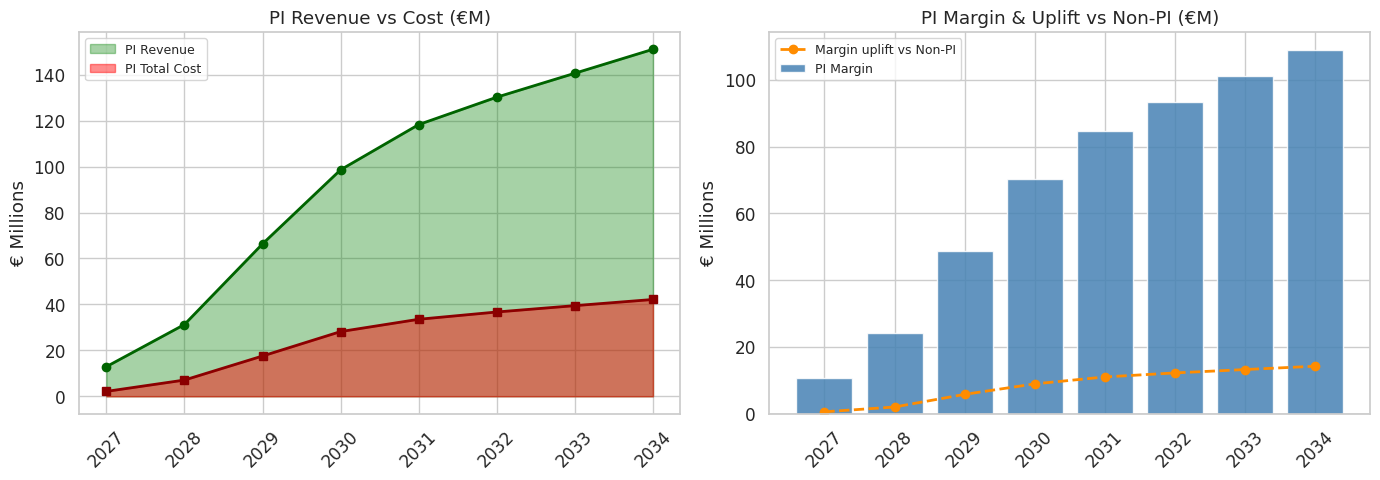

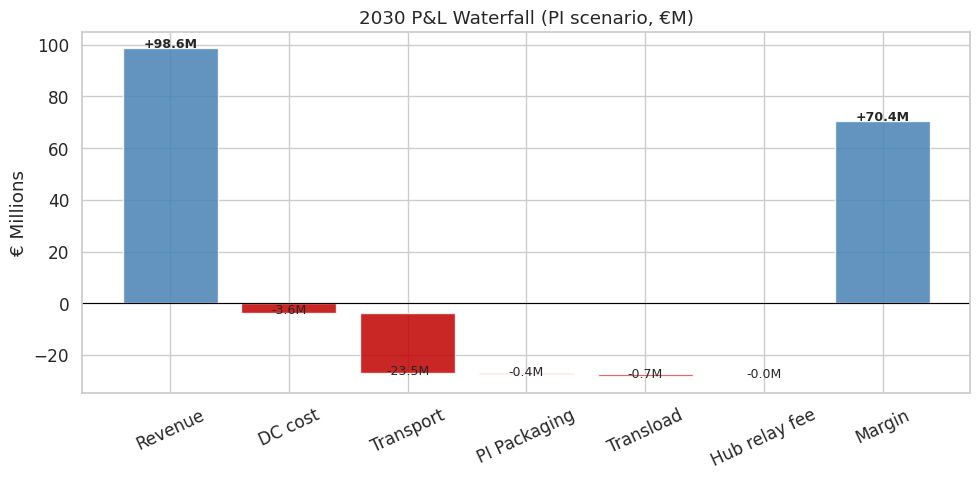

In [18]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

profit_df['pi_margin_pct'] = profit_df['pi_margin_eur'] / profit_df['pi_revenue_eur'].clip(lower=1) * 100

# Panel 1: Revenue vs cost area chart
ax = axes[0]
ax.fill_between(profit_df['year'], 0, profit_df['pi_revenue_eur'] / 1e6,
                alpha=0.35, color='green', label='PI Revenue')
ax.fill_between(profit_df['year'], 0, profit_df['total_pi_cost_eur'] / 1e6,
                alpha=0.45, color='red', label='PI Total Cost')
ax.plot(profit_df['year'], profit_df['pi_revenue_eur'] / 1e6, 'o-', color='darkgreen', lw=2)
ax.plot(profit_df['year'], profit_df['total_pi_cost_eur'] / 1e6, 's-', color='darkred', lw=2)
ax.set_title('PI Revenue vs Cost (€M)')
ax.set_ylabel('€ Millions')
ax.legend(fontsize=9)
ax.set_xticks(profit_df['year'])
ax.tick_params(axis='x', rotation=45)

# Panel 2: PI margin and margin rate
ax = axes[1]
ax.bar(profit_df['year'], profit_df['pi_margin_eur'] / 1e6, color='steelblue', alpha=0.85, label='PI Margin')
ax2_ = ax.twinx()
ax2_.plot(profit_df['year'], profit_df['pi_margin_pct'], 'o--', color='darkorange', lw=2, label='Margin %')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('PI Margin and Margin Rate')
ax.set_ylabel('€ Millions')
ax2_.set_ylabel('Margin %')
ax.set_xticks(profit_df['year'])
ax.tick_params(axis='x', rotation=45)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2_.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5_12_profitability.png', dpi=150, bbox_inches='tight')
plt.show()

# Waterfall chart for 2030 cost breakdown
res_2030_profit = next(r['profitability'] for r in results if r['year'] == 2030)
wf_items = [
    ('Revenue', res_2030_profit['pi_revenue_eur'] / 1e6, True),
    ('DC cost', -res_2030_profit['total_dc_cost_eur'] / 1e6, False),
    ('Transport', -res_2030_profit['total_transport_eur'] / 1e6, False),
    ('Last mile', -res_2030_profit['pi_lastmile_cost_eur'] / 1e6, False),
    ('PI Packaging', -res_2030_profit['pi_pack_cost_eur'] / 1e6, False),
    ('Transload', -res_2030_profit['transload_cost_eur'] / 1e6, False),
    ('Hub consolidation', -res_2030_profit['hub_consol_cost_eur'] / 1e6, False),
    ('Hub relay fee', -res_2030_profit['hub_relay_cost_eur'] / 1e6, False),
    ('Margin', res_2030_profit['pi_margin_eur'] / 1e6, True),
]
labels = [x[0] for x in wf_items]
vals = [x[1] for x in wf_items]
is_total = [x[2] for x in wf_items]

running = 0
bottoms = []
for value, total_flag in zip(vals, is_total):
    bottoms.append(0 if total_flag else running)
    if not total_flag:
        running += value

fig4, ax4 = plt.subplots(figsize=(11, 5))
for i, (label, value, total_flag, bottom) in enumerate(zip(labels, vals, is_total, bottoms)):
    color = 'steelblue' if total_flag else ('green' if value >= 0 else '#C00000')
    ax4.bar(i, value, bottom=bottom, color=color, alpha=0.85)
    ax4.text(i, bottom + value + (0.1 if value >= 0 else -0.5), f'{value:+.1f}M',
             ha='center', fontsize=9, fontweight='bold' if total_flag else 'normal')

ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels(labels, rotation=25)
ax4.set_ylabel('€ Millions')
ax4.set_title('2030 PI P&L Waterfall (€M)')
ax4.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_5_12_pl_waterfall_2030.png', dpi=150, bbox_inches='tight')
plt.show()


---
## PI Network Summary


In [ ]:
pi_dashboard = kpi_df[
    ['year', 'coverage_pct', 'relay_readiness_pct', 'mean_detour',
     'mean_otd_attainment', 'transport_cost_per_unit', 'co2_per_unit_kg']
].copy()
pi_dashboard = pi_dashboard.merge(
    profit_df[['year', 'pi_units', 'pi_margin_eur']],
    on='year',
    how='left',
)
display(pi_dashboard.set_index('year'))


---
*All Task 5 outputs in `Task5/output/`.  Figures saved as `fig_5_*.png`.*